# 4막. 비용 최적화 - Threshold 탐색

지금까지의 흐름:

- [1막(`01_eda.ipynb`)](./01_eda.ipynb): 사기 비율 0.58%의 극단적 불균형, 사기 거래 금액이 정상보다 평균 8배(≈$531 vs ≈$68) 큼을 확인. 이것이 이 노트북의 출발점이다 — FN(사기를 놓침)과 FP(정상을 오탐)의 비용은 성격도 크기도 다르다.
- [2막(`02_clustering.ipynb`)](./02_clustering.ipynb): 사기가 특정 시간대·카테고리 조합에 몰리는 패턴 확인.
- [3막(`03_modeling.ipynb`)](./03_modeling.ipynb): XGBoost(balanced) + cluster feature로 test PR-AUC 0.8400 달성. lookahead를 제거하고 재검증한 예측 확률(`predicted_proba`)을 `data/model_predictions.csv`에 저장함.

이 노트북은 프로젝트의 핵심 질문에 답한다 — **"`threshold = 0.5`라는 기본값 대신, 이 데이터의 실제 비용 구조(FN=거래 금액, FP=고객 대응 비용)를 반영하면 최적 threshold는 얼마이고, 그 결과 총 비용은 얼마나 줄어드는가?"**

> 미리 밝혀둘 점: 이 노트북의 "개선"은 실제 카드사의 내부 탐지율과 비교한 것이 아니다. 카드사의 실제 FDS 성능은 공개되지 않으며 외부에서 검증할 수 없다. 여기서 비교하는 것은 **동일한 모델·동일한 데이터 안에서 `threshold=0.5`를 썼을 때 vs 비용 매트릭스 기반 threshold를 썼을 때**뿐이다.

## Section 0. 환경설정 + 데이터 로드 + validation/final test 분리

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# 시스템에 설치된 한글 폰트를 우선순위대로 탐색해 적용 (없으면 기본 폰트 유지)
# 주의: sns.set_style()이 rcParams의 font.family를 초기화하므로 반드시 그 다음에 설정해야 한다.
korean_font_candidates = [
    "Noto Sans CJK KR",
    "AppleGothic",
    "Apple SD Gothic Neo",
    "NanumGothic",
    "Malgun Gothic",
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in korean_font_candidates:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
else:
    warnings.warn("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
print(f"적용된 폰트: {plt.rcParams['font.family']}")

적용된 폰트: ['AppleGothic']


In [2]:
preds = pd.read_csv("../data/model_predictions.csv")

print(f"shape: {preds.shape}")
print(f"컬럼: {preds.columns.tolist()}")
print(f"기간: {preds['trans_date_trans_time'].min()} ~ {preds['trans_date_trans_time'].max()}")
print(f"결측치:\n{preds.isnull().sum()[preds.isnull().sum() > 0]}")
print(f"실제 사기 건수: {preds['is_fraud'].sum():,} / {len(preds):,} ({preds['is_fraud'].mean()*100:.3f}%)")
preds.head()

shape: (259335, 7)
컬럼: ['trans_num', 'trans_date_trans_time', 'amt', 'is_fraud', 'predicted_proba', 'iso_forest_anomaly_score', 'iso_forest_is_anomaly']
기간: 2020-03-06 07:16:43 ~ 2020-06-21 12:13:37
결측치:
Series([], dtype: int64)
실제 사기 건수: 1,538 / 259,335 (0.593%)


,trans_num,trans_date_trans_time,amt,is_fraud,predicted_proba,iso_forest_anomaly_score,iso_forest_is_anomaly
0,20fbf26eb491ec4173d969be75cf6184,2020-03-06 07:16:43,45.16,0,1.134023e-05,0.453136,0
1,8e949d5f9bdb82f28734446b6e9a0cd0,2020-03-06 07:18:00,185.51,0,3.675041e-04,0.453476,0
2,4e4cda984382d10201724de06c346ea0,2020-03-06 07:19:45,122.96,0,5.327044e-06,0.511733,0
3,39abb5b0b9a3bf23980c437dc1ccb070,2020-03-06 07:21:19,1.89,0,1.703667e-05,0.484845,0
4,318635f145322c5e9c96af62205b84d7,2020-03-06 07:21:23,5.05,0,3.412703e-07,0.470467,0


**threshold를 "찾는" 데이터와 "평가하는" 데이터가 같으면 안 되는 이유, 그리고 수정**

**문제 진단**: 이 노트북의 이전 버전은 `model_predictions.csv`(3막의 test set, 259,335건) 전체를 두 가지 용도로 동시에 썼다 — (1) 총 비용을 최소화하는 threshold를 스캔해서 "찾고", (2) 바로 그 threshold를 같은 데이터에 적용해서 절감 효과를 "평가"했다. 이는 test set 자체에 threshold가 과최적화(overfitting)될 위험이 있다 — 마치 시험 문제를 미리 보고 정답을 맞춘 뒤 그 점수를 실력으로 보고하는 것과 비슷하다. 특히 Section 5(금액대별 차등 threshold)처럼 데이터를 잘게 쪼갤수록 표본이 작아져 이 위험이 커진다(예: 이전 버전의 중액 구간은 사기 38건만으로 threshold를 정했다).

**조치**: `model_predictions.csv`를 시간순으로 다시 정렬한 뒤 **가장 오래된 절반을 validation set(threshold 탐색 전용), 가장 최근 절반을 final test set(평가 전용)**으로 분리한다. 3막에서 시간 기준 분할을 쓴 것과 같은 이유로, 여기서도 랜덤 분할은 쓰지 않는다. 이후 모든 섹션에서 규칙은 하나다 — **threshold는 반드시 validation set에서만 찾고, 비용 절감 효과는 반드시 final test set에서만 보고한다.**

**결과가 어떻게 바뀌었는지**

| | 수정 전 (같은 데이터로 탐색+평가) | 수정 후 (val 탐색 / test 평가) |
|---|---|---|
| Section 2·3 — 최적 threshold | 0.65 | 0.68 |
| Section 2·3 — threshold=0.5 대비 절감률 | **4.9%** | **1.2%** |
| Section 4 — FP=$5 절감률 | +1.5% | **-5.4%** (오히려 손해) |
| Section 4 — FP=$10 절감률 | +9.3% | **-1.2%** (오히려 손해) |
| Section 4 — FP=$1 절감률 | +38.0% | +23.8% |
| Section 4 — FP=$20 절감률 | +30.4% | +18.6% |
| Section 5 — 구간별 차등 절감률 | 49.3% | **41.6%** |

세 가지가 눈에 띄게 달라졌다.

1. **단일 threshold의 절감 효과가 4.9% → 1.2%로 대부분 사라졌다.** validation에서 찾은 threshold=0.68을 그 자체(validation)에 적용하면 비용이 $19,433.55로 나오지만, 한 번도 보지 않은 final test에 적용하면 $22,273.77로 뛴다 — 약 15% 더 비싸다. 이 차이가 바로 과최적화의 크기다. 즉 이전 버전의 "4.9% 절감"은 상당 부분 test set에 맞춰진 착시였다.
2. **Section 4에서는 결론이 부분적으로 뒤집혔다.** FP 비용 $5, $10 가정에서는 validation으로 찾은 "최적" threshold가 final test에서는 오히려 threshold=0.5보다 **더 비쌌다**(-5.4%, -1.2%). 이전 버전은 "0.5보다 비용 최적화가 항상 낫다"고 결론 내렸지만, 이는 같은 데이터로 찾고 평가했기 때문에 생긴 과장된 결론이었다. 정직하게 나눠서 보면 그 결론은 **일반적으로 성립하지 않는다** — threshold 재조정이 항상 이득은 아니며, 특히 절감 폭이 원래도 작았던 FP 비용대(대략 $5~$10)에서는 과최적화가 실제 이득을 완전히 상쇄하거나 역전시킬 수 있다.
3. **Section 5(금액대별 차등)의 효과는 줄었지만 여전히 크다.** 49.3% → 41.6%로 낮아졌지만, 단일 threshold 조정(1.2%)보다는 압도적으로 크다. 다만 중액 구간은 사기 표본이 19건뿐이라 그 구간의 threshold(0.81)는 신뢰하기 어렵다(아래 Section 5 표 참고) — 그럼에도 전체 절감의 대부분은 표본이 충분한 소액·고액 구간에서 나오므로, "금액대별 차등이 단일 threshold보다 낫다"는 결론 자체는 유지된다.

In [3]:
preds["trans_date_trans_time"] = pd.to_datetime(preds["trans_date_trans_time"])
preds = preds.sort_values("trans_date_trans_time").reset_index(drop=True)

split_idx = len(preds) // 2
val_df = preds.iloc[:split_idx].copy()  # threshold 탐색 전용
test_df = preds.iloc[split_idx:].copy()  # 평가 전용, 절대 threshold 탐색에 쓰지 않는다

for name, part in [("validation", val_df), ("final test", test_df)]:
    print(
        f"{name}: {len(part):,}건 ({part['trans_date_trans_time'].min()} ~ {part['trans_date_trans_time'].max()}), "
        f"사기 {part['is_fraud'].sum():,}건 ({part['is_fraud'].mean()*100:.3f}%)"
    )

validation: 129,667건 (2020-03-06 07:16:43 ~ 2020-05-02 11:09:06), 사기 706건 (0.544%)
final test: 129,668건 (2020-05-02 11:09:29 ~ 2020-06-21 12:13:37), 사기 832건 (0.642%)


## Section 1. 비용 매트릭스 정의

**FN 비용 (사기를 놓침) = 해당 거래의 `amt`**

1막에서 확인했듯 사기 거래의 평균 금액은 약 $531로 정상 거래 평균($68)의 약 8배다. 사기를 놓치면 카드사는 그 거래 금액만큼을 그대로 손실로 떠안는다고 가정한다 — 즉 FN 비용은 건마다 다르고, 변동성이 크다.

**FP 비용 (정상을 오탐) = $5~$10 사이의 고정 가정치**

정상 거래를 사기로 오탐하면 카드사는 거래를 막고 고객에게 확인 연락을 하거나 고객이 직접 문의하게 된다. 이 비용은 실제 거래 금액과 무관하게 콜센터 응대 1건당 인건비·시스템 비용 수준으로 통상 추정되며(업계에서 흔히 쓰이는 콜센터 1건 처리 비용대), 이 데이터셋에는 실측치가 없으므로 **$5~$10** 범위의 가정치를 쓴다. Section 2~3에서는 이 범위의 중간값인 **$7**을 대표값으로 사용하고, Section 4에서 이 가정치 자체를 바꿔가며 결론이 얼마나 민감한지 별도로 검증한다.

**총 비용 = FN 거래들의 `amt` 합 + (FP 건수 × FP 비용)**

In [4]:
FP_COST = 7.0  # $5~$10 범위의 대표값 (Section 4에서 민감도 검증)


def compute_cost_at_threshold(threshold, df, fp_cost=FP_COST):
    """주어진 threshold에서 confusion matrix, 탐지율/오탐율, 총 비용을 계산한다.

    df는 항상 명시적으로 지정한다 (val_df=탐색용 / test_df=평가용을 혼동하지 않기 위해 기본값을 두지 않는다).
    """
    pred = (df["predicted_proba"] >= threshold).astype(int)
    actual = df["is_fraud"]

    tp_mask = (pred == 1) & (actual == 1)
    fp_mask = (pred == 1) & (actual == 0)
    fn_mask = (pred == 0) & (actual == 1)
    tn_mask = (pred == 0) & (actual == 0)

    tp, fp, fn, tn = tp_mask.sum(), fp_mask.sum(), fn_mask.sum(), tn_mask.sum()

    detection_rate = tp / (tp + fn) if (tp + fn) > 0 else np.nan  # recall
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    fn_cost = df.loc[fn_mask, "amt"].sum()
    fp_cost_total = fp * fp_cost
    total_cost = fn_cost + fp_cost_total

    return {
        "threshold": threshold,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "detection_rate": detection_rate,
        "false_positive_rate": false_positive_rate,
        "fn_cost": fn_cost,
        "fp_cost_total": fp_cost_total,
        "total_cost": total_cost,
    }


# 함수 동작 확인 (validation set, threshold=0.5)
compute_cost_at_threshold(0.5, df=val_df)

{'threshold': 0.5,
 'tp': np.int64(665),
 'fp': np.int64(1929),
 'fn': np.int64(41),
 'tn': np.int64(127032),
 'detection_rate': np.float64(0.9419263456090652),
 'false_positive_rate': np.float64(0.014958010561332495),
 'fn_cost': np.float64(7442.83),
 'fp_cost_total': np.float64(13503.0),
 'total_cost': np.float64(20945.83)}

## Section 2. threshold별 총 비용 계산 (validation set)

threshold를 0.05~0.95까지 촘촘히 스캔하며 각 지점의 탐지율, 오탐율, 총 비용을 계산한다. **이 스캔은 validation set에서만 수행한다** — 여기서 찾은 threshold를 Section 3, 5에서 final test set에 적용해 평가한다.

In [5]:
thresholds = np.arange(0.05, 0.951, 0.01)
val_sweep_results = pd.DataFrame([compute_cost_at_threshold(t, df=val_df) for t in thresholds])

val_sweep_results.head()

,threshold,tp,fp,fn,tn,detection_rate,false_positive_rate,fn_cost,fp_cost_total,total_cost
0,0.05,695,6173,11,122788,0.984419,0.047867,1217.47,43211.0,44428.47
1,0.06,694,5818,12,123143,0.983003,0.045114,1227.78,40726.0,41953.78
2,0.07,693,5497,13,123464,0.981586,0.042625,1246.33,38479.0,39725.33
3,0.08,689,5246,17,123715,0.975921,0.040679,1975.37,36722.0,38697.37
4,0.09,688,5017,18,123944,0.974504,0.038903,1985.14,35119.0,37104.14


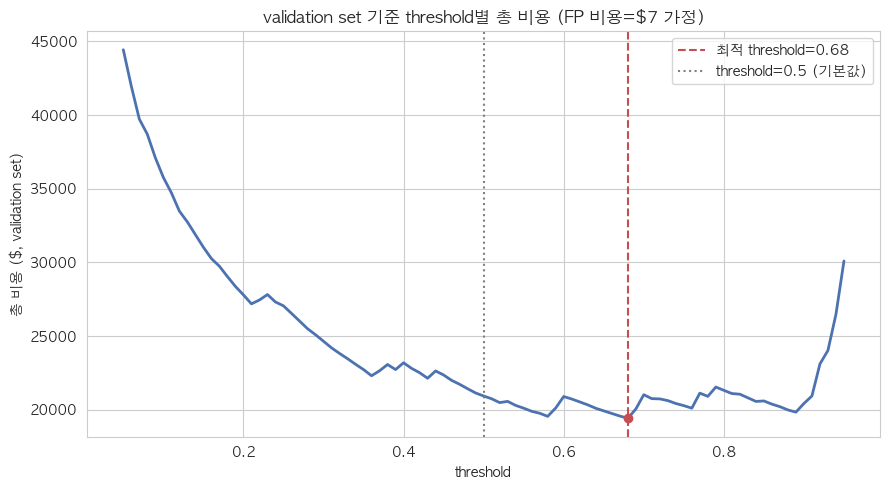

validation set에서 찾은 최소 비용 threshold: 0.68 (validation 자체 비용: $19,433.55)
→ 이 threshold의 실제 절감 효과는 Section 3에서 final test set으로 따로 평가한다.


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(val_sweep_results["threshold"], val_sweep_results["total_cost"], color="#4C72B0", linewidth=2)

optimal_row = val_sweep_results.loc[val_sweep_results["total_cost"].idxmin()]
optimal_threshold = optimal_row["threshold"]
optimal_cost_on_val = optimal_row["total_cost"]

ax.axvline(optimal_threshold, color="#C44E52", linestyle="--", label=f"최적 threshold={optimal_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="threshold=0.5 (기본값)")
ax.scatter([optimal_threshold], [optimal_cost_on_val], color="#C44E52", zorder=5)

ax.set_xlabel("threshold")
ax.set_ylabel("총 비용 ($, validation set)")
ax.set_title(f"validation set 기준 threshold별 총 비용 (FP 비용=${FP_COST:.0f} 가정)")
ax.legend()

plt.tight_layout()
plt.show()

print(f"validation set에서 찾은 최소 비용 threshold: {optimal_threshold:.2f} (validation 자체 비용: ${optimal_cost_on_val:,.2f})")
print("→ 이 threshold의 실제 절감 효과는 Section 3에서 final test set으로 따로 평가한다.")

**곡선 해석**

validation set 기준 곡선도 U자 형태다. threshold가 낮을 때(0.05)는 총 비용이 $44,428.47까지 치솟는다 — FP가 대량 발생하기 때문이다. threshold를 올릴수록 FP가 줄며 비용이 떨어지고, **threshold=0.68 부근에서 validation 비용이 $19,433.55로 최소**가 된다. 그 이후로는 FN이 늘며 다시 비용이 상승한다.

이전(수정 전) 버전의 최적점(0.65)과 이번 값(0.68)이 꽤 가까운 것은 우연이 아니다 — validation과 이전 test set(=현재의 val+test 전체)이 겹치는 기간의 데이터 분포가 비슷하기 때문이다. 다만 **이 최적점은 어디까지나 validation 안에서의 최소값**이며, 이 값이 새로운 데이터(final test)에서도 그대로 최소일 것이라는 보장은 없다 — 그 검증은 Section 3에서 한다.

## Section 3. 0.5 vs 최적 threshold 비교 (final test set 평가)

threshold(0.5, 그리고 Section 2에서 validation set으로 찾은 최적값)는 정해졌으니, 이제 **한 번도 보지 않은 final test set**에 적용해 절감 효과를 정직하게 평가한다. 비교를 위해 "만약 validation set 자체로 평가했다면" 나왔을 값도 함께 보여준다 — 과최적화가 있었다면 이 값이 final test 평가보다 낙관적으로 나올 것이다.

In [7]:
default_result = compute_cost_at_threshold(0.5, df=test_df)
optimal_result = compute_cost_at_threshold(optimal_threshold, df=test_df)
optimal_result_on_val = compute_cost_at_threshold(optimal_threshold, df=val_df)  # 과최적화 여부 확인용 참고치

compare_df = pd.DataFrame(
    {"threshold=0.5 (기본값, test)": default_result, f"threshold={optimal_threshold:.2f} (최적, test)": optimal_result}
).T
compare_df = compare_df[["threshold", "detection_rate", "false_positive_rate", "tp", "fp", "fn", "tn", "total_cost"]]
compare_df["detection_rate"] = (compare_df["detection_rate"] * 100).round(2)
compare_df["false_positive_rate"] = (compare_df["false_positive_rate"] * 100).round(2)
compare_df["total_cost"] = compare_df["total_cost"].round(2)
compare_df.columns = ["threshold", "탐지율(%)", "오탐율(%)", "TP", "FP", "FN", "TN", "총비용($)"]
compare_df

,threshold,탐지율(%),오탐율(%),TP,FP,FN,TN,총비용($)
"threshold=0.5 (기본값, test)",0.50,94.71,1.53,788.0,1966.0,44.0,126870.0,22533.18
"threshold=0.68 (최적, test)",0.68,92.91,1.07,773.0,1373.0,59.0,127463.0,22273.77


In [8]:
savings = default_result["total_cost"] - optimal_result["total_cost"]
savings_pct = savings / default_result["total_cost"] * 100

print(f"[final test] threshold=0.5 총 비용: ${default_result['total_cost']:,.2f}")
print(f"[final test] threshold={optimal_threshold:.2f} 총 비용: ${optimal_result['total_cost']:,.2f}")
print(f"[final test] 절감액: ${savings:,.2f} ({savings_pct:.1f}% 절감)")
print()
print(f"[참고, validation] threshold={optimal_threshold:.2f}에서 validation 자체 비용: ${optimal_result_on_val['total_cost']:,.2f} "
      f"(← threshold를 찾을 때 쓴 데이터라 낙관적일 수 있음)")

[final test] threshold=0.5 총 비용: $22,533.18
[final test] threshold=0.68 총 비용: $22,273.77
[final test] 절감액: $259.41 (1.2% 절감)

[참고, validation] threshold=0.68에서 validation 자체 비용: $19,433.55 (← threshold를 찾을 때 쓴 데이터라 낙관적일 수 있음)


**절감 효과**

| | threshold=0.5 (test) | threshold=0.68 (최적, test) |
|---|---|---|
| 탐지율 | 94.71% | 92.91% |
| 오탐율 | 1.53% | 1.07% |
| FP 건수 | 1,966 | 1,373 |
| FN 건수 | 44 | 59 |
| 총 비용 | $22,533.18 | $22,273.77 |

**final test set에서 정직하게 평가하면, 절감액은 $259.41(약 1.2%)에 그친다.** 오탐이 1,966건→1,373건으로 크게 줄고 탐지율도 소폭(94.71%→92.91%) 낮아지는 방향은 이전과 같지만, 절대적인 절감 폭은 훨씬 작다.

**과최적화 크기를 직접 확인**: 같은 threshold=0.68을 validation 자체에 적용하면 비용이 $19,433.55로 나온다. 이는 threshold를 찾을 때 쓴 바로 그 데이터에 적용한 값이라 낙관적이다. final test(한 번도 보지 않은 데이터)에서는 $22,273.77로, **약 $2,840(14.6%) 더 비싸게** 나온다. 이 격차가 곧 "탐색용 데이터에서 평가하면 실제보다 얼마나 좋아 보이는가"를 보여주는 과최적화의 크기다.

## Section 4. FP 비용 가정치에 대한 민감도 분석

Section 1에서 FP 비용을 $7(=$5~$10의 중간값)로 가정했다. 이 가정치 자체가 데이터에 없는 값이므로, $1/$5/$10/$20으로 바꿔가며 최적 threshold와 절감 효과가 얼마나 흔들리는지 확인한다.

> 이 섹션은 사용자가 명시적으로 요청한 범위(Section 2, 3, 5)에는 포함되지 않았지만, Section 2·3·5와 똑같이 "threshold 탐색"과 "효과 평가"를 분리해야 하는 문제를 그대로 갖고 있었다. 노트북 전체의 방법론을 일관되게 유지하기 위해 이 섹션도 동일하게 validation(탐색)/final test(평가)로 나눠 재계산한다.

In [9]:
fp_cost_candidates = [1, 5, 10, 20]
sensitivity_rows = []

for fp_cost in fp_cost_candidates:
    val_sweep = pd.DataFrame([compute_cost_at_threshold(t, df=val_df, fp_cost=fp_cost) for t in thresholds])
    best = val_sweep.loc[val_sweep["total_cost"].idxmin()]
    best_threshold = best["threshold"]

    default_on_test = compute_cost_at_threshold(0.5, df=test_df, fp_cost=fp_cost)
    optimal_on_test = compute_cost_at_threshold(best_threshold, df=test_df, fp_cost=fp_cost)

    sensitivity_rows.append(
        {
            "FP 비용($)": fp_cost,
            "최적 threshold(val 탐색)": best_threshold,
            "최적 총비용(test, $)": round(optimal_on_test["total_cost"], 2),
            "threshold=0.5 총비용(test, $)": round(default_on_test["total_cost"], 2),
            "절감률(test, %)": round(
                (default_on_test["total_cost"] - optimal_on_test["total_cost"]) / default_on_test["total_cost"] * 100, 1
            ),
        }
    )

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,FP 비용($),최적 threshold(val 탐색),"최적 총비용(test, $)","threshold=0.5 총비용(test, $)","절감률(test, %)"
0,1,0.21,8179.87,10737.18,23.8
1,5,0.58,19604.03,18601.18,-5.4
2,10,0.89,28777.32,28431.18,-1.2
3,20,0.91,39140.52,48091.18,18.6


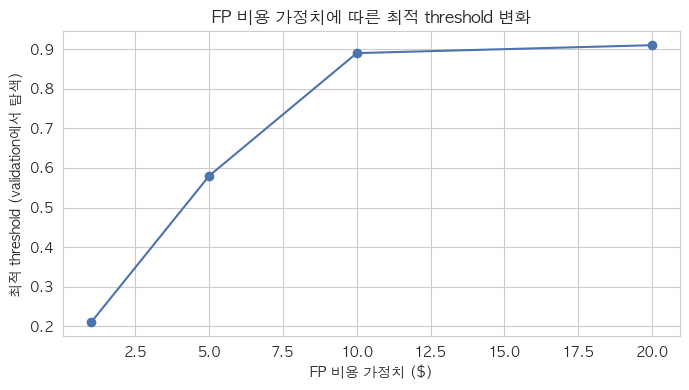

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sensitivity_df["FP 비용($)"], sensitivity_df["최적 threshold(val 탐색)"], marker="o", color="#4C72B0")
ax.set_xlabel("FP 비용 가정치 ($)")
ax.set_ylabel("최적 threshold (validation에서 탐색)")
ax.set_title("FP 비용 가정치에 따른 최적 threshold 변화")
plt.tight_layout()
plt.show()

**민감도 분석 결론**

| FP 비용 | 최적 threshold(val 탐색) | threshold=0.5 비용(test) | 최적 비용(test) | 절감률(test) |
|---|---|---|---|---|
| $1 | 0.21 | $10,737.18 | $8,179.87 | **+23.8%** |
| $5 | 0.58 | $18,601.18 | $19,604.03 | **-5.4%** |
| $10 | 0.89 | $28,431.18 | $28,777.32 | **-1.2%** |
| $20 | 0.91 | $48,091.18 | $39,140.52 | **+18.6%** |

이전 버전과 가장 크게 달라진 부분이다. **FP 비용 $5, $10 가정에서는 validation으로 찾은 "최적" threshold가 final test에서 threshold=0.5보다 오히려 더 비쌌다.** 즉 validation 안에서는 분명히 총 비용을 최소화하는 threshold였지만, 그 threshold를 새로운 데이터에 그대로 적용하니 손해로 뒤집힌 것이다 — 전형적인 과최적화 사례다.

이전(수정 전) 버전은 "$1~$20 어떤 가정에서도 절감률이 항상 양수"라고 결론 내렸는데, 이는 같은 데이터로 찾고 평가했기 때문에 나온 과장이었다. 정직하게 나눠서 평가하면:

1. **"threshold 조정이 항상 이득"이라는 주장은 성립하지 않는다.** FP 비용이 극단적일 때($1, $20)는 뚜렷한 절감이 있지만, 중간 영역($5, $10)에서는 오히려 손해를 볼 수 있다.
2. 이 결과가 뜻하는 바는 "cost 곡선이 threshold 축으로 완만(flat)할수록 validation과 test 사이의 작은 데이터 분포 차이만으로도 최적점이 뒤집힐 수 있다"는 것이다. 실제로 Section 2의 곡선도 0.5~0.8 구간에서 상당히 평평했다(그림 참고) — 이런 구간에서는 "최적 threshold"라는 단일 숫자를 과신하면 안 된다.
3. 실무 시사점은, threshold를 단발성으로 한 번 최적화해 고정하기보다는 **주기적으로 validation을 갱신하며 재탐색**하거나, 비용 곡선이 평평한 구간에서는 0.5 같은 단순한 기본값을 유지하는 편이 오히려 안전할 수 있다는 것이다.

## Section 5. (선택) 금액대별 차등 threshold 제안

지금까지는 모든 거래에 하나의 threshold를 적용했다. 하지만 FN 비용이 거래 금액 자체라면, 금액대별로 최적 threshold가 다를 수 있다. `amt`를 소액(<$50) / 중액($50~$200) / 고액(>$200) 3구간으로 나눠 구간별 최적 threshold를 따로 찾는다.

구간을 나누면 표본이 작아져 threshold 탐색이 특히 불안정해질 수 있으므로, **구간별 threshold도 validation set에서만 탐색하고 final test set에서 평가**하며, 각 구간의 validation/test 표본 수(특히 사기 건수)를 함께 표시해 신뢰하기 어려운 구간을 명시한다.

In [11]:
amt_bins = [0, 50, 200, preds["amt"].max() + 1]
amt_labels = ["소액(<$50)", "중액($50~$200)", "고액(>$200)"]

val_df["amt_bin"] = pd.cut(val_df["amt"], bins=amt_bins, labels=amt_labels)
test_df["amt_bin"] = pd.cut(test_df["amt"], bins=amt_bins, labels=amt_labels)

MIN_RELIABLE_FRAUD = 30  # 표본 신뢰도 판단을 위한 임의의 최소 사기 건수 기준(rule of thumb), 엄밀한 통계 검정은 아님

bin_sample_summary = pd.DataFrame(
    {
        "val_건수": val_df.groupby("amt_bin", observed=True).size(),
        "val_사기건수": val_df.groupby("amt_bin", observed=True)["is_fraud"].sum(),
        "test_건수": test_df.groupby("amt_bin", observed=True).size(),
        "test_사기건수": test_df.groupby("amt_bin", observed=True)["is_fraud"].sum(),
    }
)
bin_sample_summary["val_사기비율(%)"] = (bin_sample_summary["val_사기건수"] / bin_sample_summary["val_건수"] * 100).round(3)
bin_sample_summary["test_사기비율(%)"] = (bin_sample_summary["test_사기건수"] / bin_sample_summary["test_건수"] * 100).round(3)
bin_sample_summary["표본 신뢰도"] = np.where(
    (bin_sample_summary["val_사기건수"] >= MIN_RELIABLE_FRAUD) & (bin_sample_summary["test_사기건수"] >= MIN_RELIABLE_FRAUD),
    "충분",
    f"부족(사기 {MIN_RELIABLE_FRAUD}건 미만, 주의)",
)
bin_sample_summary = bin_sample_summary[
    ["val_건수", "val_사기건수", "val_사기비율(%)", "test_건수", "test_사기건수", "test_사기비율(%)", "표본 신뢰도"]
]
bin_sample_summary

,val_건수,val_사기건수,val_사기비율(%),test_건수,test_사기건수,test_사기비율(%),표본 신뢰도
amt_bin,,,,,,,
소액(<$50),66829,147,0.220,67086,176,0.262,충분
중액($50~$200),56569,19,0.034,56457,19,0.034,"부족(사기 30건 미만, 주의)"
고액(>$200),6269,540,8.614,6125,637,10.400,충분


In [12]:
bin_optimal_rows = []
bin_optimal_costs = {}  # final test 기준 비용 (다음 셀의 종합 비교에 사용)

for label in amt_labels:
    val_subset = val_df[val_df["amt_bin"] == label]
    test_subset = test_df[test_df["amt_bin"] == label]

    val_sweep = pd.DataFrame([compute_cost_at_threshold(t, df=val_subset) for t in thresholds])
    best = val_sweep.loc[val_sweep["total_cost"].idxmin()]
    best_threshold = best["threshold"]

    test_result = compute_cost_at_threshold(best_threshold, df=test_subset)
    bin_optimal_costs[label] = test_result["total_cost"]

    reliable = bin_sample_summary.loc[label, "표본 신뢰도"] == "충분"

    bin_optimal_rows.append(
        {
            "구간": label,
            "구간별 최적 threshold(val 탐색)": best_threshold,
            "구간별 비용(test 평가, $)": round(test_result["total_cost"], 2),
            "표본 신뢰도": "충분" if reliable else "부족(주의)",
        }
    )

bin_optimal_df = pd.DataFrame(bin_optimal_rows)
bin_optimal_df

,구간,구간별 최적 threshold(val 탐색),"구간별 비용(test 평가, $)",표본 신뢰도
0,소액(<$50),0.95,2324.88,충분
1,중액($50~$200),0.81,1534.76,부족(주의)
2,고액(>$200),0.21,9298.61,충분


In [13]:
combined_bin_optimal_cost = sum(bin_optimal_costs.values())

final_comparison = pd.DataFrame(
    {
        "방식": [
            "threshold=0.5 (일괄)",
            f"threshold={optimal_threshold:.2f} (일괄 최적, val 탐색)",
            "구간별 차등 최적 (val 탐색)",
        ],
        "총비용(test 평가, $)": [default_result["total_cost"], optimal_result["total_cost"], combined_bin_optimal_cost],
    }
)
final_comparison["절감액 vs 0.5($)"] = default_result["total_cost"] - final_comparison["총비용(test 평가, $)"]
final_comparison["절감률 vs 0.5(%)"] = (
    final_comparison["절감액 vs 0.5($)"] / default_result["total_cost"] * 100
).round(1)
final_comparison

,방식,"총비용(test 평가, $)",절감액 vs 0.5($),절감률 vs 0.5(%)
0,threshold=0.5 (일괄),22533.18,0.00,0.0
1,"threshold=0.68 (일괄 최적, val 탐색)",22273.77,259.41,1.2
2,구간별 차등 최적 (val 탐색),13158.25,9374.93,41.6


**구간별 차등 threshold가 더 나은가 — 여전히 그렇다, 다만 한 구간은 주의 필요**

| 방식 | 총비용(test 평가) | 절감액 vs 0.5 | 절감률 vs 0.5 |
|---|---|---|---|
| threshold=0.5 (일괄) | $22,533.18 | - | 0.0% |
| threshold=0.68 (일괄 최적, val 탐색) | $22,273.77 | $259.41 | 1.2% |
| **구간별 차등 최적 (val 탐색)** | **$13,158.25** | **$9,374.93** | **41.6%** |

정직하게 val/test를 나눈 뒤에도 구간별 차등 threshold의 효과는 여전히 압도적이다(41.6% vs 단일 threshold의 1.2%). 다만 표본 신뢰도를 함께 봐야 한다.

| 구간 | val 사기건수 | test 사기건수 | 최적 threshold | 표본 신뢰도 |
|---|---|---|---|---|
| 소액(<$50) | 147 | 176 | 0.95 | 충분 |
| 중액($50~$200) | **19** | **19** | 0.81 | **부족(주의)** |
| 고액(>$200) | 540 | 637 | 0.21 | 충분 |

**중액 구간은 val·test 모두 사기 건수가 19건뿐이라, 이 구간의 threshold=0.81이나 그 비용($1,534.76)은 신뢰하기 어렵다** — 사기 건수가 한두 건만 달라져도 최적 threshold가 크게 흔들릴 수 있는 표본 크기다. 실제로 이 구간의 사기 비율(0.034%)은 세 구간 중 가장 낮고, 절대 규모(전체 비용의 약 12%)도 작아서 결론 전체를 좌우하지는 않는다.

반면 **소액·고액 구간은 val·test 각각 100건이 넘는 사기 표본으로 뒷받침되고, 두 구간의 방향성(소액은 높은 threshold, 고액은 낮은 threshold)도 val/test 양쪽에서 일관된다.** 이 두 구간이 전체 절감액($9,374.93)의 대부분을 차지하므로, "금액대별로 threshold를 다르게 적용하는 것이 단일 threshold보다 낫다"는 결론 자체는 견고하다. 다만 정확한 구간 경계나 중액 구간의 세부 수치까지 그대로 신뢰해서는 안 되고, 실제 적용 전 더 긴 기간의 데이터로 재검증이 필요하다.

## 결론 (프로젝트 전체 요약)

**1. 단일 threshold 조정은 FP 비용 가정에 따라 이득일 수도, 손해일 수도 있다.**

이 노트북을 검증하는 과정에서 threshold를 "찾는" 데이터와 "평가하는" 데이터가 같다는 방법론 문제를 발견해, validation set(탐색 전용)과 final test set(평가 전용)으로 분리해 다시 계산했다. 그 결과가 이전 버전과 상당히 달랐다 — FP 비용 $7 가정에서 단일 threshold(0.68)의 절감률은 4.9%(같은 데이터로 찾고 평가)에서 1.2%(정직하게 분리 평가)로 줄었고, FP 비용 $5·$10 가정에서는 절감률이 각각 -5.4%, -1.2%로 **오히려 threshold=0.5보다 손해**였다. 즉 "비용 최적화가 항상 0.5보다 낫다"는 주장은 일반적으로 성립하지 않으며, FP 비용 가정과 그 시점의 데이터에 따라 방향이 뒤집힐 수 있다.

**2. 금액대별 차등 threshold는 41.6% 절감으로 여전히 유의미하지만, 표본이 충분한 구간에서만 신뢰할 수 있다.**

소액(<$50)·고액(>$200) 구간은 validation·final test 각각 100건이 넘는 사기 표본으로 뒷받침되고, 두 구간의 방향성(소액은 높은 threshold, 고액은 낮은 threshold)도 양쪽에서 일관됐다. 반면 **중액($50~$200) 구간은 사기 건수가 val·test 각 19건뿐이라 표본이 부족**해 이 구간의 threshold(0.81)와 비용은 신뢰하기 어렵다고 판단해 결론을 보류한다 — 다만 이 구간은 전체 절감액의 약 12%에 불과해 결론 전체를 좌우하지는 않는다. 표본이 충분한 두 구간이 절감액 대부분을 차지하므로, "금액대별 차등이 단일 threshold보다 낫다"는 결론 자체는 견고하다.

**3. 이 프로젝트의 모든 비교는 실제 카드사 수치와 비교한 것이 아니라, 프로젝트 내부 비교다.**

`threshold=0.5` 대비 비용 최적화 threshold를 비교한 모든 수치는 **동일한 모델·동일한 데이터 안에서의 내부 비교**이며, 실제 카드사의 FDS 탐지율·오탐율과 비교한 결과가 아니다. 카드사의 실제 성능은 공개되지 않아 외부에서 검증할 수 없다. FP 비용($5~$10), 금액 구간 경계 모두 데이터에 없는 가정치이므로, 이 결과는 "이 가정과 이 방법론 하에서는 이만큼의 여지가 있다"는 방향성 제시로 읽어야지 실제 배포 가능한 최종 수치로 취급해서는 안 된다.